In [1]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("OASIS INFOBYTE - Data Analytics")
print("EDA on Retail Sales Data")
print("Setup completed successfully!")

OASIS INFOBYTE - Data Analytics
EDA on Retail Sales Data
Setup completed successfully!


In [3]:
# Load the retail sales dataset

df = pd.read_csv("retail_sales_dataset.csv")

print("Dataset loaded successfully!")
print("Shape of dataset:", df.shape)

df.head()

Dataset loaded successfully!
Shape of dataset: (1000, 9)


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [4]:
# Basic information about the dataset

print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB


In [5]:
# Statistical summary

df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [6]:
# Check for missing values

print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


In [7]:
# Check for duplicate rows

print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [8]:
# Display column names

print("Columns in the dataset:")
print(df.columns.tolist())

Columns in the dataset:
['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount']


In [9]:
# Sales by product category

category_sales = df.groupby("Product Category")["Total Amount"].sum().sort_values(ascending=False)

print("Total sales by product category:")
print(category_sales)

Total sales by product category:
Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64


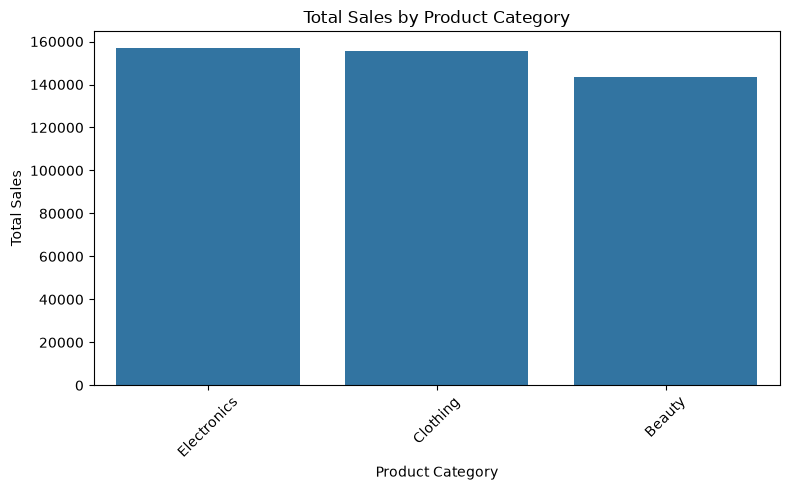

In [10]:
# Visualize sales by product category

plt.figure(figsize=(8, 5))
sns.barplot(x=category_sales.index, y=category_sales.values)
plt.title("Total Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

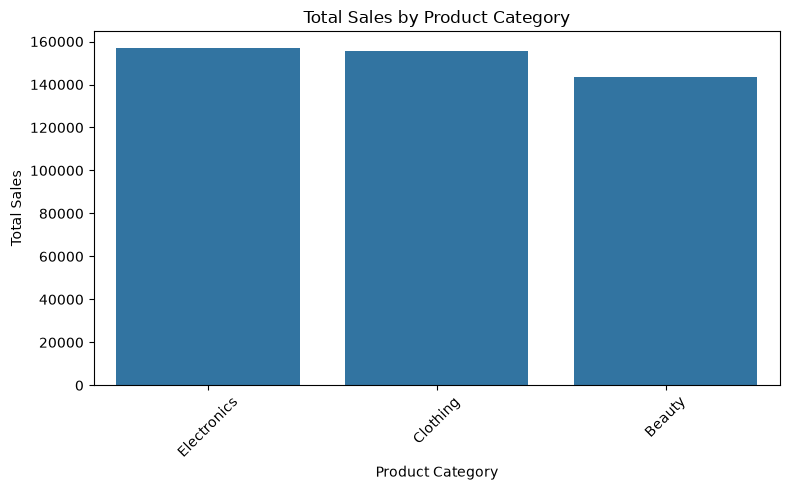

In [11]:
# Visualize sales by product category

plt.figure(figsize=(8, 5))
sns.barplot(x=category_sales.index, y=category_sales.values)
plt.title("Total Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
# Descriptive Statistics

# Select numerical columns
numerical_columns = df.select_dtypes(include=np.number).columns

print("Numerical Columns:")
print(numerical_columns.tolist())

print("\nMean:")
print(df[numerical_columns].mean())

print("\nMedian:")
print(df[numerical_columns].median())

print("\nMode:")
print(df[numerical_columns].mode().iloc[0])

print("\nStandard Deviation:")
print(df[numerical_columns].std())

Numerical Columns:
['Transaction ID', 'Age', 'Quantity', 'Price per Unit', 'Total Amount']

Mean:
Transaction ID    500.500
Age                41.392
Quantity            2.514
Price per Unit    179.890
Total Amount      456.000
dtype: float64

Median:
Transaction ID    500.5
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64

Mode:
Transaction ID     1.0
Age               43.0
Quantity           4.0
Price per Unit    50.0
Total Amount      50.0
Name: 0, dtype: float64

Standard Deviation:
Transaction ID    288.819436
Age                13.681430
Quantity            1.132734
Price per Unit    189.681356
Total Amount      559.997632
dtype: float64


In [13]:
# Convert Date column to datetime format

df["Date"] = pd.to_datetime(df["Date"])

print("Date column converted successfully!")
print(df["Date"].dtype)

Date column converted successfully!
datetime64[us]


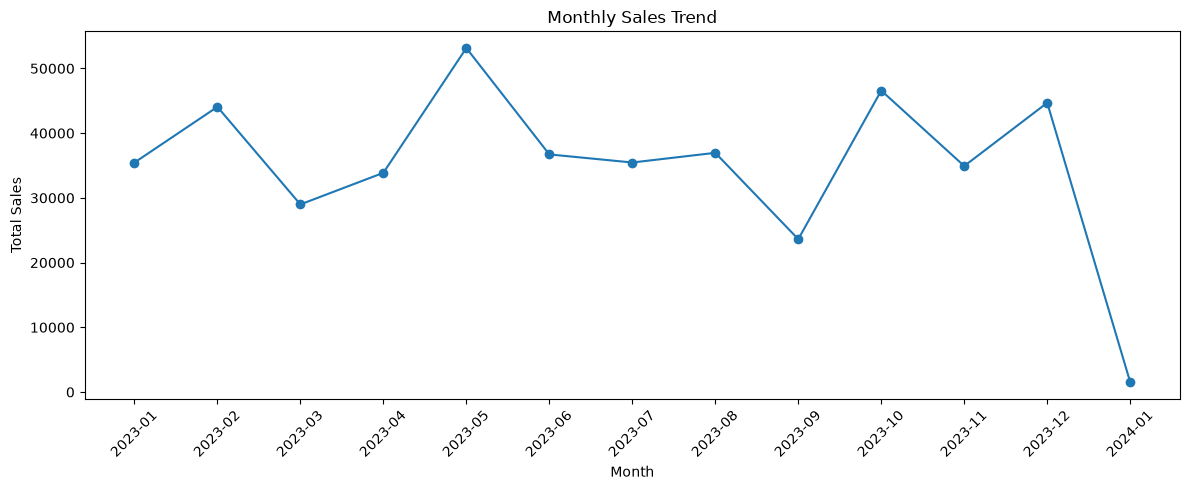

In [14]:
# Monthly Sales Trend

monthly_sales = df.groupby(df["Date"].dt.to_period("M"))["Total Amount"].sum()

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index.astype(str), monthly_sales.values, marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation – Monthly Sales Trend

The monthly sales trend shows how total sales changed over time. 
The graph helps identify months with higher or lower sales and reveals overall sales patterns.

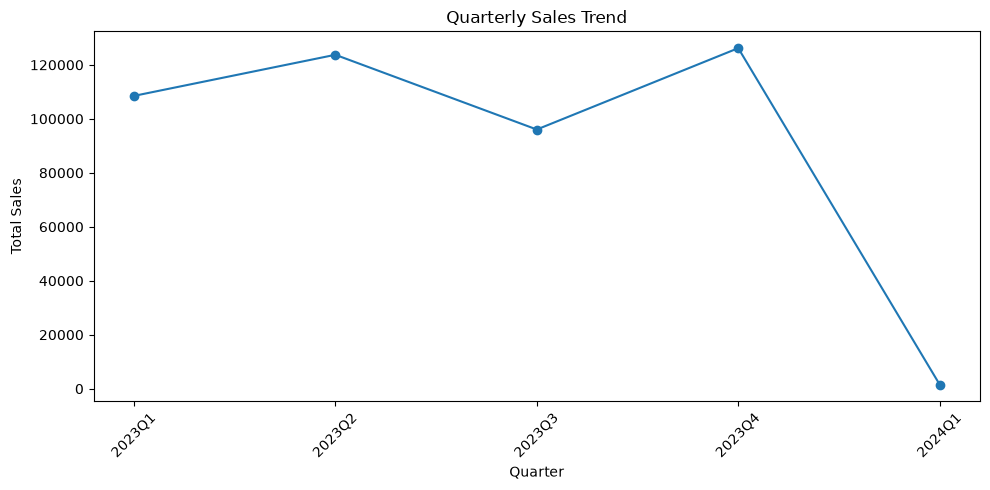

In [15]:
# Quarterly Sales Trend

quarterly_sales = df.groupby(df["Date"].dt.to_period("Q"))["Total Amount"].sum()

plt.figure(figsize=(10, 5))
plt.plot(quarterly_sales.index.astype(str), quarterly_sales.values, marker="o")

plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation – Quarterly Sales Trend

The quarterly sales trend shows the changes in total sales across different quarters.
It helps identify periods of higher and lower sales and provides a broader view of the business performance over time.

In [16]:
# Create customer age groups

bins = [0, 18, 25, 35, 45, 55, 65, 100]
labels = ["Under 18", "18-25", "26-35", "36-45", "46-55", "56-65", "65+"]

df["Age Group"] = pd.cut(df["Age"], bins=bins, labels=labels)

print("Age groups created successfully!")
print(df["Age Group"].value_counts().sort_index())

Age groups created successfully!
Age Group
Under 18     21
18-25       148
26-35       205
36-45       202
46-55       229
56-65       195
65+           0
Name: count, dtype: int64


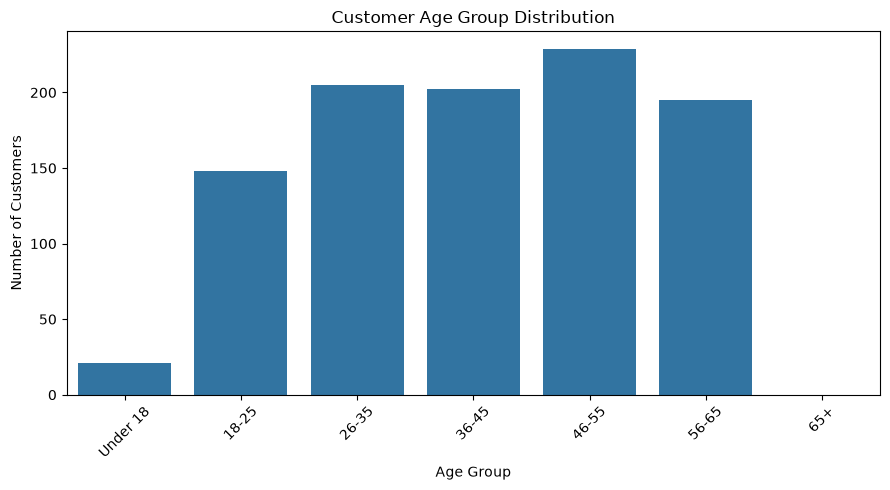

In [17]:
# Customer Age Group Distribution

age_group_counts = df["Age Group"].value_counts().sort_index()

plt.figure(figsize=(9, 5))
sns.barplot(x=age_group_counts.index, y=age_group_counts.values)

plt.title("Customer Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation – Customer Age Group Distribution

The age-group distribution shows the number of customers in different age categories.
It helps identify the major customer age groups represented in the retail sales dataset.

Gender distribution:
Gender
Female    510
Male      490
Name: count, dtype: int64


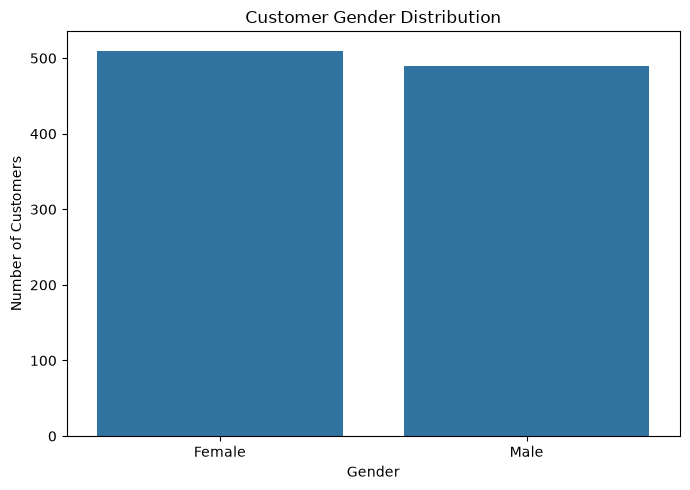

In [18]:
# Gender Distribution

gender_counts = df["Gender"].value_counts()

print("Gender distribution:")
print(gender_counts)

plt.figure(figsize=(7, 5))
sns.barplot(x=gender_counts.index, y=gender_counts.values)

plt.title("Customer Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

### Observation – Gender Distribution

The gender distribution shows the number of customers belonging to each gender category.
This helps understand the composition of the customer base in the retail sales dataset.

In [19]:
print(df.columns.tolist())

['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount', 'Age Group']


In [20]:
# Product Category Sales Analysis

top_categories = (
    df.groupby("Product Category")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

print("Top-selling product categories by quantity:")
print(top_categories)

Top-selling product categories by quantity:
Product Category
Clothing       894
Electronics    849
Beauty         771
Name: Quantity, dtype: int64


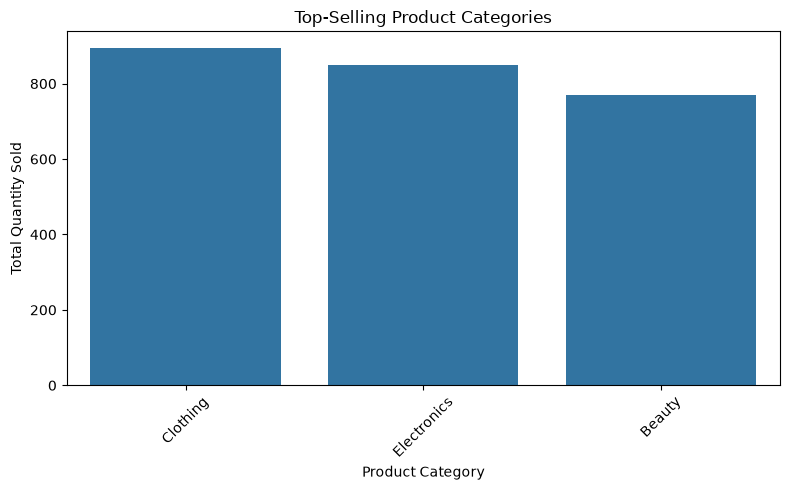

In [21]:
# Top-selling Product Categories

plt.figure(figsize=(8, 5))
sns.barplot(x=top_categories.index, y=top_categories.values)

plt.title("Top-Selling Product Categories")
plt.xlabel("Product Category")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation – Product Category Analysis

The chart shows the total quantity sold for each product category.
Since the dataset does not contain individual product names, the analysis is performed at the product-category level.
This helps identify which categories have higher sales volume.

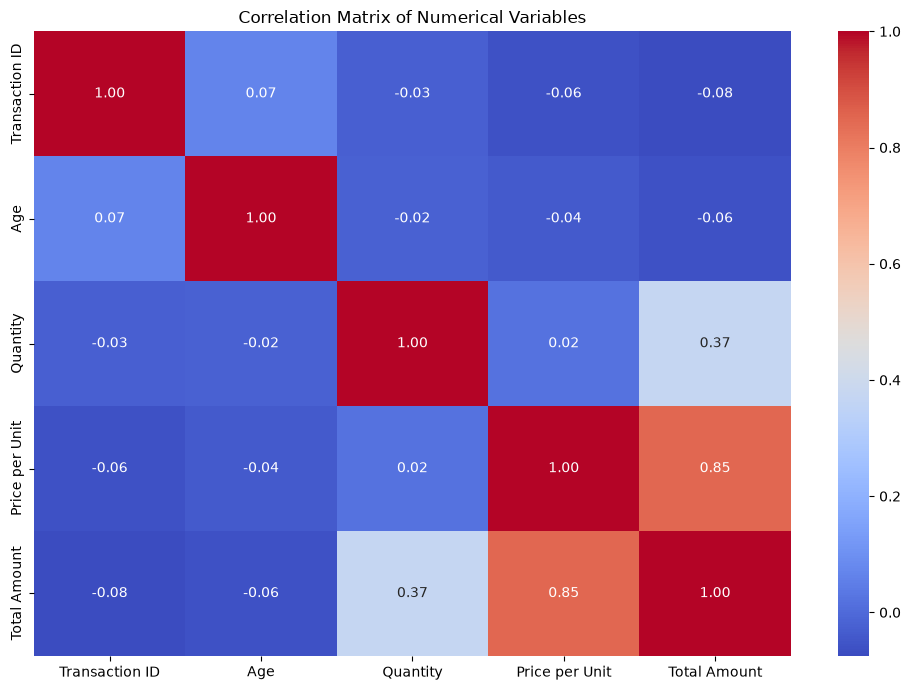

In [22]:
# Correlation Heatmap

numerical_data = df.select_dtypes(include=np.number)

plt.figure(figsize=(10, 7))
sns.heatmap(
    numerical_data.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

### Observation – Correlation Heatmap

The correlation heatmap shows the relationships between numerical variables in the dataset.
Values closer to 1 indicate a strong positive relationship, while values closer to -1 indicate a strong negative relationship.
Values near 0 indicate a weak linear relationship.

Average spending by gender:
Gender
Female    456.549020
Male      455.428571
Name: Total Amount, dtype: float64


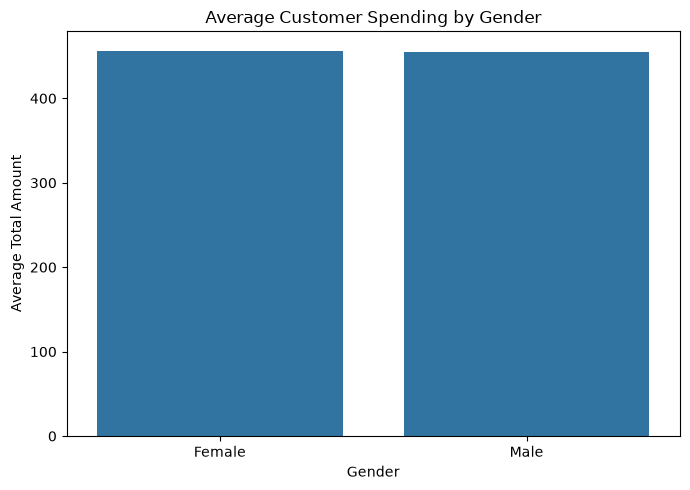

In [23]:
# Average Spending by Gender

average_spending = df.groupby("Gender")["Total Amount"].mean().sort_values(ascending=False)

print("Average spending by gender:")
print(average_spending)

plt.figure(figsize=(7, 5))
sns.barplot(x=average_spending.index, y=average_spending.values)

plt.title("Average Customer Spending by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Total Amount")
plt.tight_layout()
plt.show()

### Observation – Average Spending by Gender

The chart compares the average spending amount across different gender categories.
It provides an additional view of customer purchasing behaviour and can help identify differences in average transaction value between the groups.

# Conclusion and Business Recommendations

## Conclusion

The exploratory data analysis provided useful insights into customer demographics,
product categories, sales trends, and purchasing behaviour in the retail sales dataset.
Monthly and quarterly analysis helped identify changes in sales over time, while
customer demographic analysis showed the distribution of customers by age group and gender.
Product category analysis highlighted differences in sales volume across categories.
The correlation analysis also helped identify relationships between numerical variables.

## Business Recommendations

1. **Focus on high-performing product categories:** 
   The business can maintain sufficient inventory and promotional activities for
   categories with higher sales volume.

2. **Use customer demographic insights:** 
   Customer age-group and gender distributions can be used to design more relevant
   marketing campaigns and customer engagement strategies.

3. **Monitor sales trends regularly:** 
   Monthly and quarterly sales trends should be monitored to identify periods of
   higher and lower sales and support better inventory and promotional planning.

4. **Use data-driven inventory planning:** 
   Quantity sold and sales trends can be considered when planning inventory levels
   to reduce the risk of overstocking or stock shortages.